In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


In [3]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv("/kaggle/input/digit-recognizer/train.csv")
df.sample(5)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
24205,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
31034,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
25972,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1172,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
21656,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Data has too many cols and mostly sparse 

In [ ]:
df.shape

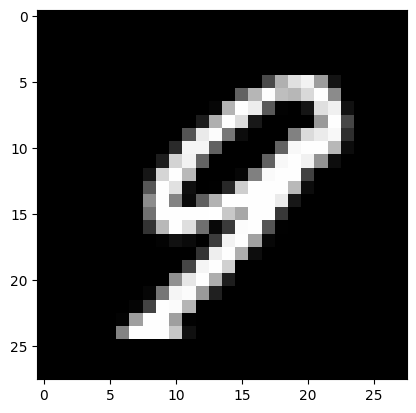

In [5]:
plt.imshow( df.iloc[13686, 1:].values.reshape(28,28), cmap='gray')

In [6]:
x = df.iloc[: , 1:]
y = df.iloc[:,:1]

# train_test_split

In [7]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test  = train_test_split( x, y, test_size=0.2 , random_state=42)
x_train.shape

(33600, 784)

# KNN

In [9]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

In [10]:

knn.fit( x_train , y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier()

In [11]:
y_pred = knn.predict(x_test)

In [15]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pred , y_test)

0.9648809523809524

# PCA

step1 - standersize - mean centring

In [20]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
x_train = scale.fit_transform(x_train)
x_test = scale.transform(x_test)

step2 - applying PCA

In [21]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 784)    # 784 -> 784

x_train_1 = pca.fit_transform(x_train)
x_test_1 = pca.transform(x_test)

In [25]:
val = pca.explained_variance_ratio_

In [27]:
l = np.cumsum( val )

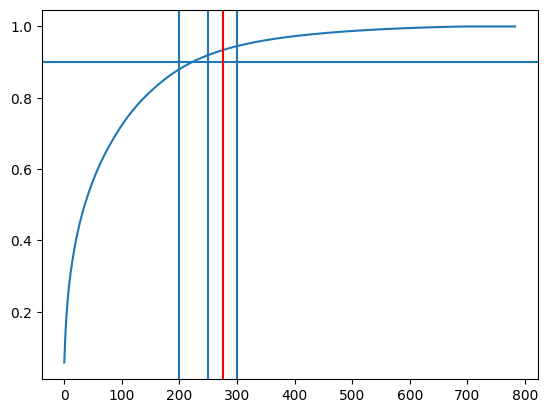

In [48]:
plt.plot(l)
plt.axhline(0.9)
plt.axvline(200)
plt.axvline(300)
plt.axvline(250)
plt.axvline(275 , c='red')

# final predictions

In [49]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 275)    # 784 -> 275

x_train_2 = pca.fit_transform(x_train)
x_test_2 = pca.transform(x_test)

knn.fit( x_train_2 , y_train)

y_pred = knn.predict(x_test_2)
from sklearn.metrics import accuracy_score
accuracy_score(y_pred , y_test) 

/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


0.9478571428571428

In [50]:
test = pd.read_csv("/kaggle/input/digit-recognizer/test.csv")
test.shape

(28000, 784)

In [51]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 98)    # 784 -> 100

x_train_k = pca.fit_transform(x_train)
test = pca.transform(test)

knn.fit( x_train_k , y_train)

y_pred = knn.predict(test)
y_pred.shape

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


(28000,)

In [54]:
final_predictions = y_pred
lis = np.arange(1,28001)

submission_d = pd.DataFrame({
    'ImageId': lis , 
    'Label': final_predictions.astype(int)
})


submission_d.to_csv('/kaggle/working/submission_final_predictions.csv', index=False)

In [55]:
submission_d

,ImageId,Label
0,1,2
1,2,0
2,3,8
3,4,0
4,5,3
...,...,...
27995,27996,9
27996,27997,7
27997,27998,3
27998,27999,9
